In [263]:
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

In [264]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
T_MAX = 0.95

In [265]:
np.random.seed(42)
torch.manual_seed(42)

In [266]:
def to_float(x): return (x + 1.0) / 2.0
def to_spins(x): return np.where(x > 0.5, 1, -1)

In [267]:
def corrupt(x, t):
    noise = torch.rand_like(x)
    return x * (1 - t) + noise * t

In [268]:
class UNet(nn.Module):
    def __init__(self, in_channels=2, out_channels=1):
        
        super().__init__()
        
        self.down_layers = torch.nn.ModuleList([ 
            nn.Conv2d(in_channels, 32, kernel_size=5, padding=2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
        ])
        self.up_layers = torch.nn.ModuleList([
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
            nn.Conv2d(64, 32, kernel_size=5, padding=2),
            nn.Conv2d(32, out_channels, kernel_size=5, padding=2), 
        ])
        
        self.act = nn.SiLU()
        self.downscale = nn.MaxPool2d(2)
        self.upscale = nn.Upsample(scale_factor=2)

    def forward(self, x, t):
        
        t_ch = t.view(-1, 1, 1, 1).expand(-1, 1, x.shape[2], x.shape[3])
        x = torch.cat([x, t_ch], dim=1)
        
        h = []
        
        for i, l in enumerate(self.down_layers):
            x = self.act(l(x))
            if i < 2:
              h.append(x)
              x = self.downscale(x)
              
        for i, l in enumerate(self.up_layers):
            if i > 0:
              x = self.upscale(x)
              x += h.pop()
            x = self.act(l(x)) if i < 2 else torch.sigmoid(l(x))
            
        return x

In [269]:
def train(epochs=40, batch_size=64, lr=1e-3):

    dataset = torch.from_numpy(to_float(np.load("ising_dataset_32x32.npy"))).unsqueeze(1).to(DEVICE).float()
    model = UNet().to(DEVICE)
    loss_fn = nn.MSELoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    
    losses = []
    
    for epoch in range(epochs):
        
        perm = torch.randperm(len(dataset), device=DEVICE)
        ep_losses = []
        
        for x in range(0, len(dataset), batch_size):
            
            batch = dataset[perm[x : x + batch_size]]
            
            t = torch.rand(len(batch), device=DEVICE) * T_MAX
            noisy_batch = corrupt(batch, t.view(len(batch), 1, 1, 1))

            pred = model(noisy_batch, t)
            loss = loss_fn(pred, batch)
    
            opt.zero_grad()
            loss.backward()
            opt.step()
    
            losses.append(loss.item())
            ep_losses.append(loss.item())
            
        avg_loss = sum(ep_losses) / len(ep_losses)
        print(f'Finished epoch {epoch+1}. Average loss for this epoch: {avg_loss:05f}')

    plt.plot(losses)
    plt.ylim(0, 0.3)
    plt.show()
    
    return model

In [270]:
def generate(model, steps=300):
    
    model.eval()
    noise = torch.rand(1, 1, 32, 32, device=DEVICE)

    with torch.no_grad():
        
        x = noise.clone()
        amount = np.linspace(T_MAX, 0.0, steps, endpoint=False)
        
        for t in amount:
            
            t0 = torch.tensor([t], device=DEVICE).float()
            t1 = t0 - T_MAX / steps
            
            x = model(x, t0) * (1 - t1) + noise * t1
        
    return x.squeeze().cpu().numpy()

Finished epoch 1. Average loss for this epoch: 0.143869
Finished epoch 2. Average loss for this epoch: 0.096549
Finished epoch 3. Average loss for this epoch: 0.081073
Finished epoch 4. Average loss for this epoch: 0.073215
Finished epoch 5. Average loss for this epoch: 0.070128
Finished epoch 6. Average loss for this epoch: 0.069880
Finished epoch 7. Average loss for this epoch: 0.068443
Finished epoch 8. Average loss for this epoch: 0.065115
Finished epoch 9. Average loss for this epoch: 0.065483
Finished epoch 10. Average loss for this epoch: 0.065456
Finished epoch 11. Average loss for this epoch: 0.066991
Finished epoch 12. Average loss for this epoch: 0.063830
Finished epoch 13. Average loss for this epoch: 0.063819
Finished epoch 14. Average loss for this epoch: 0.062737
Finished epoch 15. Average loss for this epoch: 0.062171
Finished epoch 16. Average loss for this epoch: 0.062109
Finished epoch 17. Average loss for this epoch: 0.061229
Finished epoch 18. Average loss for this

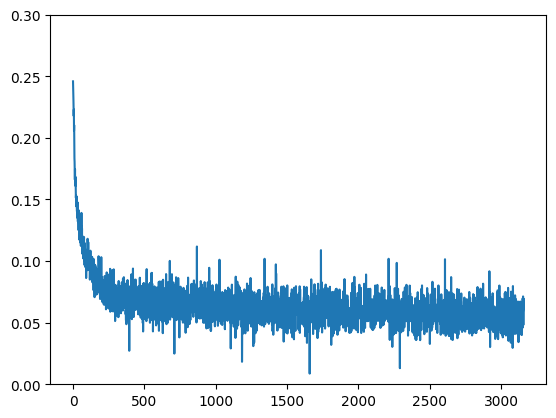

In [271]:
model = train()

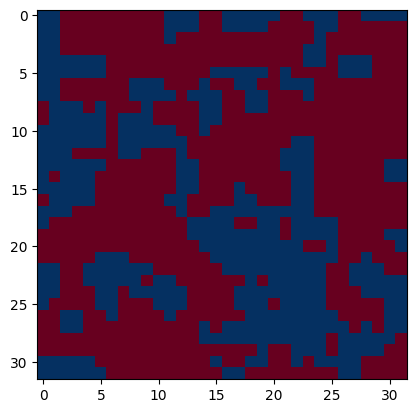

In [278]:
grid = to_spins(generate(model))
plt.imshow(grid, cmap='RdBu')
plt.show()